In [1]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits
import re
import json
import pickle

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Start in code cell 7 if CombinedDataset.nc is already created.


Some Additional Filtering that wasn't included in the original data consolidation workflow

In [ ]:
# The path for HAFS consolidated Date
folder_path = 'Model_Data/CompleteData'

# HAFS Data is in multiple NC files. Consolidate_Data creates one dataset
ds = utils.consolidate_data(folder_path)

# Checking for NA's
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')

# Limiting frames to tropical storm strength or stronger (17 m/s or stronger)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)

# Only using storms in the Northern Hemisphere
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)

Function to get frame intensity change. Lead time is customizable but defaults to 24 hours in the future.

In [ ]:
def get_future_intensity(links, current_timestep = 'f024', future_timestep = 'f048'):
    
    atm_args = dict(typeOfKey = 'isobaricInhPa',filename="Model_Data/temp_gribs/atm_temp.grb2" )
    sfc_args = dict(typeOfKey = 'meanSea',filename="Model_Data/temp_gribs/sfc_temp.grb2")
    minimum_central_pressures = []
    max_winds = []

    for link in links:

        link = re.sub(current_timestep, future_timestep, link)

        sfc_df = utils.download_and_open(link, **sfc_args)

        sfc_center = utils.get_sfc_center(sfc_df, next_step = True)

        if not sfc_center:
            minimum_central_pressures.append(None)
            max_winds.append(None)
            continue
        minimum_central_pressures.append(sfc_center['mslp'])
        
        atm_df = utils.download_and_open(link, **atm_args)
        sfc_layer = atm_df.sel(isobaricInhPa = sfc_center['mslp'], method = 'nearest')

        max_wind = np.nanmax(np.sqrt(sfc_layer['u'].values**2 + sfc_layer['v'].values**2))
        max_winds.append(max_wind)

    return {'24hr Minimum Central Pressure': minimum_central_pressures, '24hr Max Winds': max_winds}


In [ ]:
results = get_future_intensity(ds_cleaned.isel(levels = 0)['frame_link'].values)

with open('intensity_change.pkl', 'wb') as file:
    pickle.dump(results, file)

In [ ]:
ds_cleaned['24HrMaxWinds'] = (('frame_number'), np.squeeze(results['24hr Max Winds']))
ds_cleaned['24HrMinimumCentralPressure'] = (('frame_number'), np.squeeze(results['24hr Minimum Central Pressure']))

In [ ]:
ds_cleaned.to_netcdf('CombinedDataset.nc')

Start Here if CombinedDataset.nc is already created.

In [2]:
ds_cleaned = xr.open_dataset('Model_Data/CompleteData/CombinedDataset.nc')

In [3]:
ds_cleaned

<xarray.Dataset> Size: 9GB
Dimensions:                         (frame_number: 429, levels: 3, angle: 720,
                                     radius: 501)
Coordinates:
  * frame_number                    (frame_number) int32 2kB 0 3 4 ... 598 599
    valid_time                      (frame_number) datetime64[ns] 3kB ...
  * levels                          (levels) object 24B 'sfc' '700' '200'
  * angle                           (angle) float64 6kB 0.0 0.5 ... 359.0 359.5
  * radius                          (radius) float64 4kB 0.0 0.5 ... 249.5 250.0
Data variables: (12/15)
    frame_link                      (frame_number, levels) object 10kB ...
    center_pressure                 (frame_number, levels) float32 5kB ...
    max_wind                        (frame_number, levels) float32 5kB ...
    storm_heading                   (frame_number, levels) float64 10kB ...
    24Hr Max Winds                  (frame_number) float32 2kB ...
    24Hr Minimum Central Pressure   (frame_number) float32 2kB ...
    ...                              ...
    rh                              (levels, frame_number, angle, radius) float32 2GB ...
    t                               (levels, frame_number, angle, radius) float32 2GB ...
    u                               (levels, frame_number, angle, radius) float32 2GB ...
    v                               (levels, frame_number, angle, radius) float32 2GB ...
    center_lat                      (levels, frame_number) float64 10kB ...
    center_lon                      (levels, frame_number) float64 10kB ...
Attributes:
    history:   Created on 2026-03-22
    Overview:  Data originally obtained from the HAFS Repository (https://reg...

In [3]:
ds_cleaned = ds_cleaned.dropna(dim = 'frame_number', how = 'any')

In [9]:
# Creating the values to grade against. (Minimum Central Pressure and Maximum Surface Wind)

mslp = ds_cleaned['center_pressure'].values[:,0]
max_winds = ds_cleaned['max_wind'].values[:,0]
pressure_change = ds_cleaned['24HrMinimumCentralPressure'].values - mslp
wind_change = ds_cleaned['24HrMaxWinds'].values - max_winds

In [5]:
pressure_change[wind_change > 30]

array([-48.191956, -30.710693, -55.983154], dtype=float32)

In [ ]:
# Normalizing data assuming gaussian distribution

normalized_data_gh_sfc = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [ ]:
plt.hist(normalized_data_rh_700.reshape(-1,1))

In [4]:
# Normalizing data while keeping underlying distribution

normalized_data_gh_sfc = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [ ]:
plt.hist(normalized_data_rh_700.reshape(-1,1))

In [5]:
# Constructing 700mb level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_700 = np.stack((
                          normalized_data_gh_700, normalized_data_t_700, normalized_data_rh_700,
                          ), 
                          axis = 0).reshape(397, 3 * 720 * 501)
heights_700 = np.stack(normalized_data_gh_700,axis = 0).reshape(397, 1 * 720 * 501)
t_700 = np.stack(normalized_data_t_700,axis = 0).reshape(397, 1 * 720 * 501)
rh_700 = np.stack(normalized_data_rh_700,axis = 0).reshape(397, 1 * 720 * 501)


In [ ]:
# Constructing surface level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_sfc = np.stack((
                          normalized_data_gh_sfc, normalized_data_t_sfc, normalized_data_rh_sfc,
                          ), 
                          axis = 0).reshape(397, 3 * 720 * 501)
heights_sfc = np.stack(normalized_data_gh_sfc,axis = 0).reshape(397, 1 * 720 * 501)
t_sfc = np.stack(normalized_data_t_sfc,axis = 0).reshape(397, 1 * 720 * 501)
rh_sfc = np.stack(normalized_data_rh_sfc,axis = 0).reshape(397, 1 * 720 * 501)

In [ ]:
# Constructing a composite surface/700mb level dataset. Array contains surface 
# temperature data, and surface and 700mb geopotential heights. Met values were
# selected based on best results from the individual UMAP reductions.

combined_sfc700_gph_t = np.stack((
                          normalized_data_gh_sfc, normalized_data_gh_700, normalized_data_t_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)

Creating Surface Level UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_Fullsfc_n3 = reducer3.fit_transform(combined_sfc)
# embedding_GHsfc_n3 = reducer3.fit_transform(heights_sfc)
# embedding_Tsfc_n3 = reducer3.fit_transform(t_sfc)
# embedding_RHsfc_n3 = reducer3.fit_transform(rh_sfc)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
embedding_Fullsfc_n5 = reducer5.fit_transform(combined_sfc)
embedding_GHsfc_n5 = reducer5.fit_transform(heights_sfc)
embedding_Tsfc_n5 = reducer5.fit_transform(t_sfc)
embedding_RHsfc_n5 = reducer5.fit_transform(rh_sfc)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_Fullsfc_n15 = reducer15.fit_transform(combined_sfc)
# embedding_GHsfc_n15 = reducer15.fit_transform(heights_sfc)
# embedding_Tsfc_n15 = reducer15.fit_transform(t_sfc)
# embedding_RHsfc_n15 = reducer15.fit_transform(rh_sfc)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_Fullsfc_n10 = reducer10.fit_transform(combined_sfc)
# embedding_GHsfc_n10 = reducer10.fit_transform(heights_sfc)
# embedding_Tsfc_n10 = reducer10.fit_transform(t_sfc)
# embedding_RHsfc_n10 = reducer10.fit_transform(rh_sfc)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_Fullsfc_n20 = reducer20.fit_transform(combined_sfc)
# embedding_GHsfc_n20 = reducer20.fit_transform(heights_sfc)
# embedding_Tsfc_n20 = reducer20.fit_transform(t_sfc)
# embedding_RHsfc_n20 = reducer20.fit_transform(rh_sfc)


Creating 700mb Level UMAP Reductions

In [6]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_Full700_n3 = reducer3.fit_transform(combined_700)
# embedding_GH700_n3 = reducer3.fit_transform(heights_700)
# embedding_T700_n3 = reducer3.fit_transform(t_700)
# embedding_RH700_n3 = reducer3.fit_transform(rh_700)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_Full700_n5 = reducer5.fit_transform(combined_700)
embedding_GH700_n5 = reducer5.fit_transform(heights_700)
# embedding_T700_n5 = reducer5.fit_transform(t_700)
# embedding_RH700_n5 = reducer5.fit_transform(rh_700)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_Full700_n15 = reducer15.fit_transform(combined_700)
# embedding_GH700_n15 = reducer15.fit_transform(heights_700)
# embedding_T700_n15 = reducer15.fit_transform(t_700)
# embedding_RH700_n15 = reducer15.fit_transform(rh_700)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_Full700_n10 = reducer10.fit_transform(combined_700)
# embedding_GH700_n10 = reducer10.fit_transform(heights_700)
# embedding_T700_n10 = reducer10.fit_transform(t_700)
# embedding_RH700_n10 = reducer10.fit_transform(rh_700)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_Full700_n20 = reducer20.fit_transform(combined_700)
# embedding_GH700_n20 = reducer20.fit_transform(heights_700)
# embedding_T700_n20 = reducer20.fit_transform(t_700)
# embedding_RH700_n20 = reducer20.fit_transform(rh_700)

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Creating Composite UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_composite_n3 = reducer3.fit_transform(combined_sfc700_gph_t)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_composite_n5 = reducer5.fit_transform(combined_sfc700_gph_t)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_composite_n15 = reducer15.fit_transform(combined_sfc700_gph_t)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_composite_n10 = reducer10.fit_transform(combined_sfc700_gph_t)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_composite_n20 = reducer20.fit_transform(combined_sfc700_gph_t)


Plotting UMAP compared to Minimum Central Pressure

In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface Fields')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,1].set_title('700mb Fields')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(mslp_im, ax = ax[3,1], location = 'bottom', label = 'Minimum Central Pressure (mb)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Minimum Central Pressure', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 15, Random State = 42, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Max Winds

In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface Fields')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = 'Maximum Windspeed (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('700mb Fields')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(mslp_im, ax = ax[3,1], location = 'bottom', label = 'Maximum Windspeed (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Maximum Windspeed', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 15, Random State = 42, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Pressure Change 24hrs

NameError: name 'embedding_GHsfc_n5' is not defined

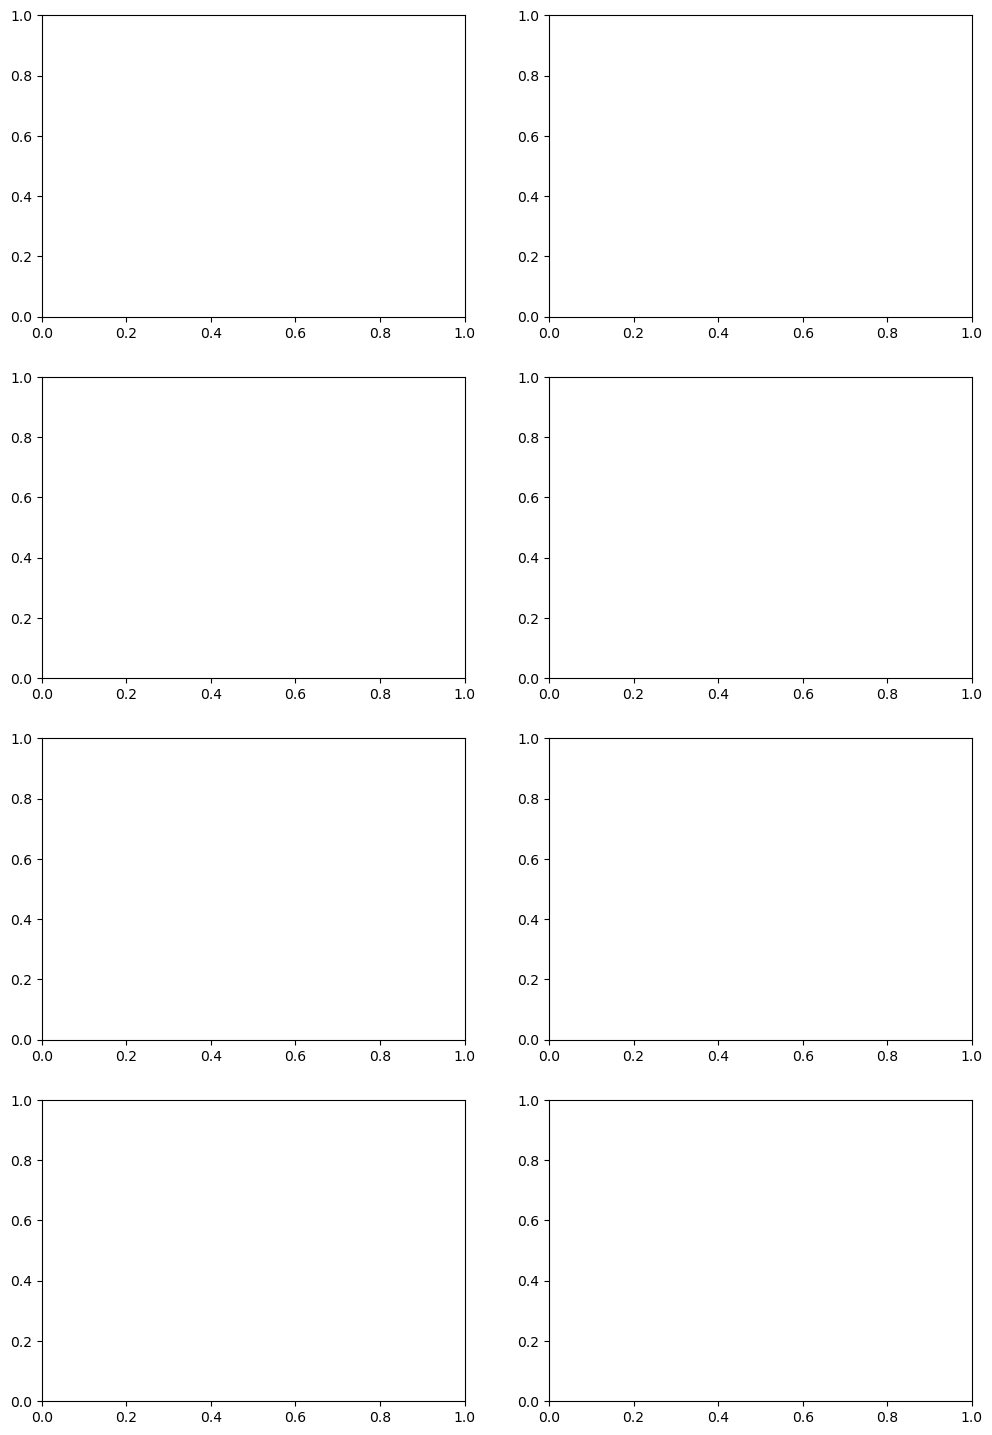

In [34]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Pressure Change (mb)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Pressure Change (mb)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Pressure Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 15, Random State = 42, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Maximum Windspeed Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 15, Random State = 42, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


In [7]:

filter_y = embedding_GH700_n5[:,1]>9
filter_x = embedding_GH700_n5[:,0] <5
strengthening1_filter_700mbgph = filter_x * filter_y

filter_y = embedding_GH700_n5[:,1] < 7.5
filter_x = embedding_GH700_n5[:,0] < 0
strengthening2_filter_700mbgph = filter_x * filter_y

filter_y =  (embedding_GH700_n5[:,1] > -1) & (embedding_GH700_n5[:,1] < 1)
filter_x = (embedding_GH700_n5[:,0] > 5) & (embedding_GH700_n5[:,0] < 7.5)
weakening1_filter_700mbgph = filter_x * filter_y

filter_y =  (embedding_GH700_n5[:,1] < 1)
filter_x =  (embedding_GH700_n5[:,0] < 3)
weakening2_filter_700mbgph = filter_x * filter_y

In [13]:
strengthening1_wind_change = wind_change[strengthening1_filter_700mbgph]
avg_strengthening1_wind_change = np.mean(strengthening1_wind_change)

strengthening2_wind_change = wind_change[strengthening2_filter_700mbgph]
avg_strengthening2_wind_change = np.mean(strengthening2_wind_change)

weakening1_wind_change = wind_change[weakening1_filter_700mbgph]
avg_weakening1_wind_change = np.mean(weakening1_wind_change)

weakening2_wind_change = wind_change[weakening2_filter_700mbgph]
avg_weakening2_wind_change = np.mean(weakening2_wind_change)

wind_change_min = np.min(wind_change)
wind_change_max = np.max(wind_change)

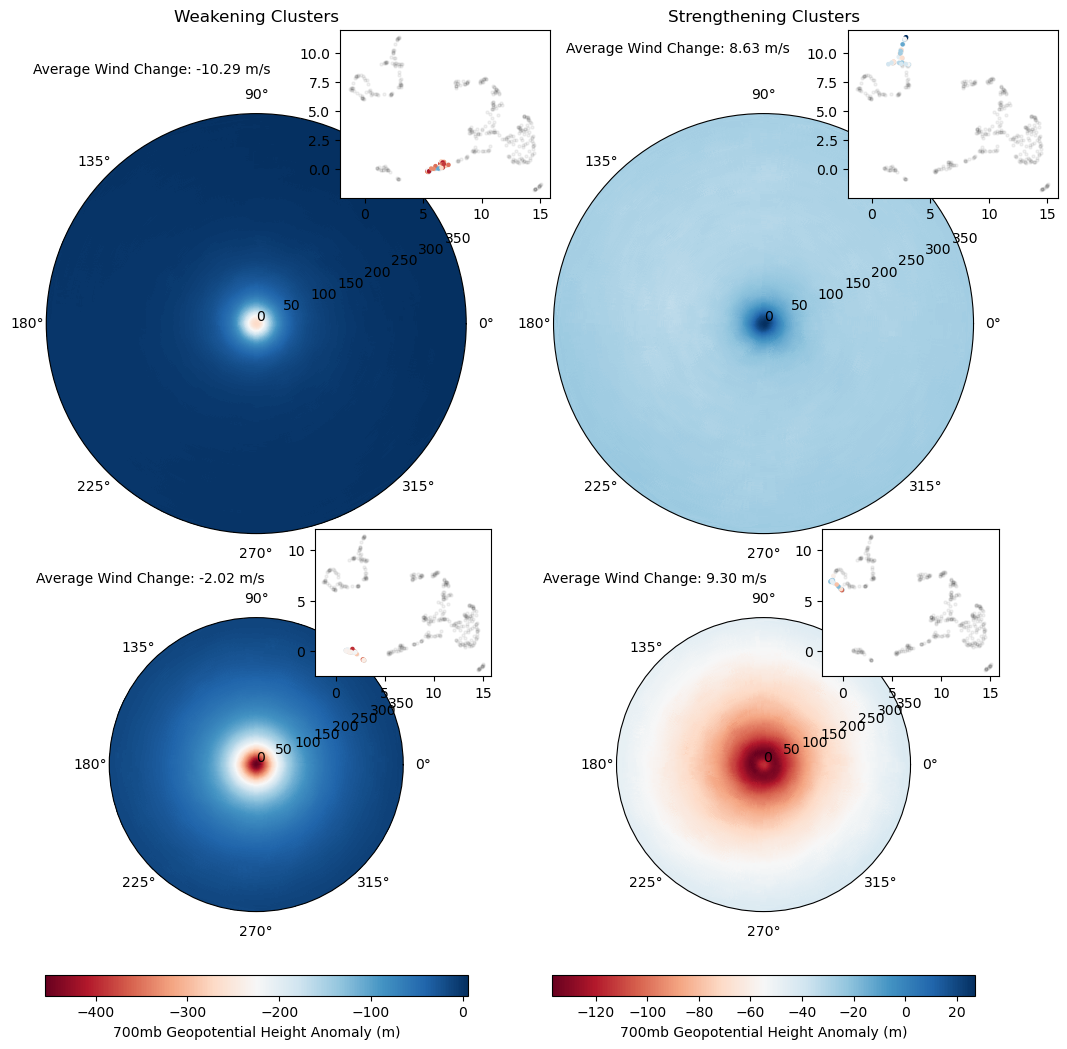

In [54]:
angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values
ds_700gph = ds_cleaned['gh'].isel(levels = 1).values
mean_height_700 = np.mean(ds_700gph, axis=0)

strengthening1_mean = np.mean(ds_700gph[strengthening1_filter_700mbgph,:,:],axis = 0)
strengthening1_anomaly = strengthening1_mean - mean_height_700

strengthening2_mean = np.mean(ds_700gph[strengthening2_filter_700mbgph,:,:],axis = 0)
strengthening2_anomaly = strengthening2_mean - mean_height_700

weakening1_mean = np.mean(ds_700gph[weakening1_filter_700mbgph,:,:],axis = 0)
weakening1_anomaly = weakening1_mean - mean_height_700

weakening2_mean = np.mean(ds_700gph[weakening2_filter_700mbgph,:,:],axis = 0)
weakening2_anomaly = weakening2_mean - mean_height_700

wk_min = np.min([weakening1_anomaly, weakening2_anomaly])
wk_max = np.max([weakening1_anomaly, weakening2_anomaly])
st_min = np.min([strengthening1_anomaly, strengthening2_anomaly])
st_max = np.max([strengthening1_anomaly, strengthening2_anomaly])
fig, ax = plt.subplots(nrows= 2, ncols=2, figsize=(12, 12),subplot_kw={'projection': 'polar'})

R, Theta = np.meshgrid(radius, angle)

wk1 = ax[0,0].pcolormesh(R, Theta, weakening1_anomaly, vmin = wk_min, vmax = wk_max, cmap = 'RdBu')
ax[0,0].grid(False)
ax[0,0].text(2.3,575, f'Average Wind Change: {avg_weakening1_wind_change:.2f} m/s')
ax[0,0].set_title('Weakening Clusters')
ax00_inset = ax[0,0].inset_axes([.7, .8, .5, .4])
ax00_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax00_inset.scatter(embedding_GH700_n5[weakening1_filter_700mbgph,0], embedding_GH700_n5[weakening1_filter_700mbgph,1], 
                   c = weakening1_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)

wk2 = ax[1,0].pcolormesh(R, Theta, weakening2_anomaly, vmin = wk_min, vmax = wk_max, cmap = 'RdBu')
ax[1,0].grid(False)
ax[1,0].text(2.45,700, f'Average Wind Change: {avg_weakening2_wind_change:.2f} m/s')
ax10_inset = ax[1,0].inset_axes([.7, .8, .6, .5])
ax10_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax10_inset.scatter(embedding_GH700_n5[weakening2_filter_700mbgph,0], embedding_GH700_n5[weakening2_filter_700mbgph,1], 
                   c = weakening2_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)

st1 = ax[0,1].pcolormesh(R, Theta, strengthening1_anomaly, vmin = st_min, vmax = st_max, cmap = 'RdBu')
ax[0,1].grid(False)
ax[0,1].text(2.2,575, f'Average Wind Change: {avg_strengthening1_wind_change:.2f} m/s')
ax[0,1].set_title('Strengthening Clusters')
ax01_inset = ax[0,1].inset_axes([.7, .8, .5, .4])
ax01_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax01_inset.scatter(embedding_GH700_n5[strengthening1_filter_700mbgph,0], embedding_GH700_n5[strengthening1_filter_700mbgph,1], 
                   c = strengthening1_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)

st2 = ax[1,1].pcolormesh(R, Theta, strengthening2_anomaly, vmin = st_min, vmax = st_max, cmap = 'RdBu')
ax[1,1].grid(False)
ax[1,1].text(2.45,700, f'Average Wind Change: {avg_strengthening2_wind_change:.2f} m/s')
ax11_inset = ax[1,1].inset_axes([.7, .8, .6, .5])
ax11_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax11_inset.scatter(embedding_GH700_n5[strengthening2_filter_700mbgph,0], embedding_GH700_n5[strengthening2_filter_700mbgph,1], 
                   c = strengthening2_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)
# cb1_axe = fig.add_axes([.05, 0.05, .4,0.15])
fig.colorbar(wk2, ax = ax[1,0], location = 'bottom', label = '700mb Geopotential Height Anomaly (m)')
fig.colorbar(st2, ax = ax[1,1], location = 'bottom', label = '700mb Geopotential Height Anomaly (m)')








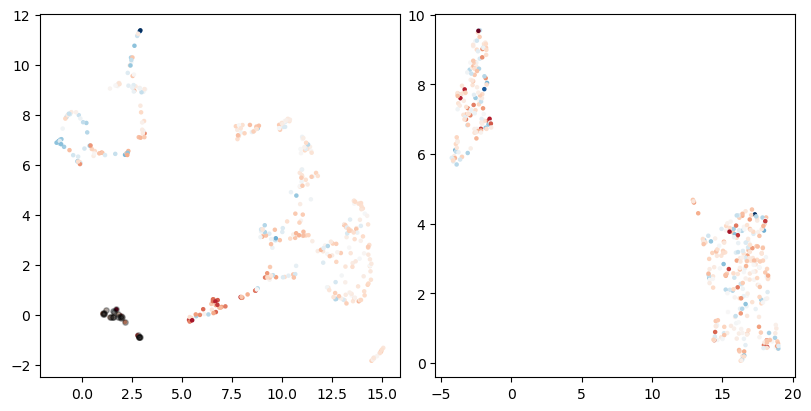

In [16]:
filter_y = embedding_Full700_n5[:,1] > 5
filter_x = embedding_Full700_n5[:,0] < 0
cluster1_filter_700mbFull = filter_x * filter_y

filter_y = embedding_Full700_n5[:,1] < 6
filter_x = embedding_Full700_n5[:,0] > 10
cluster2_filter_700mbFull = filter_x * filter_y



In [ ]:
angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values
ds_700gph = ds_cleaned['gh'].isel(levels = 1).values
mean_height_700 = np.mean(ds_700gph, axis=0)

strengthening1_mean = np.mean(ds_700gph[strengthening1_filter_700mbgph,:,:],axis = 0)
strengthening1_anomaly = strengthening1_mean - mean_height_700

strengthening2_mean = np.mean(ds_700gph[strengthening2_filter_700mbgph,:,:],axis = 0)
strengthening2_anomaly = strengthening2_mean - mean_height_700

weakening1_mean = np.mean(ds_700gph[weakening1_filter_700mbgph,:,:],axis = 0)
weakening1_anomaly = weakening1_mean - mean_height_700

weakening2_mean = np.mean(ds_700gph[weakening2_filter_700mbgph,:,:],axis = 0)
weakening2_anomaly = weakening2_mean - mean_height_700

In [ ]:
fig, ax = plt.subplots(nrows= 2, ncols=2, figsize=(12, 12),subplot_kw={'projection': 'polar'})

R, Theta = np.meshgrid(radius, angle)

wk1 = ax[0,0].pcolormesh(R, Theta, weakening1_anomaly, cmap = 'RdBu')
ax[0,0].grid(False)
wk2 = ax[1,0].pcolormesh(R, Theta, weakening2_anomaly, cmap = 'RdBu')
ax[1,0].grid(False)
st1 = ax[0,1].pcolormesh(R, Theta, strengthening1_anomaly, cmap = 'RdBu')
ax[0,1].grid(False)
st2 = ax[1,1].pcolormesh(R, Theta, strengthening2_anomaly, cmap = 'RdBu')
ax[1,1].grid(False)

fig.colorbar(st2, location = '')